In [1]:
import numpy as np
import pandas as pd

df = pd.read_csv('file_updated.csv')
#strip whitespace from column names
df.columns = df.columns.str.strip()
print(df['Label'].value_counts())

Label
BENIGN    537749
DDoS      380699
Name: count, dtype: int64


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918448 entries, 0 to 918447
Data columns (total 79 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Destination Port             918448 non-null  int64  
 1   Flow Duration                918448 non-null  int64  
 2   Total Fwd Packets            918448 non-null  int64  
 3   Total Backward Packets       918448 non-null  int64  
 4   Total Length of Fwd Packets  918448 non-null  int64  
 5   Total Length of Bwd Packets  918448 non-null  int64  
 6   Fwd Packet Length Max        918448 non-null  int64  
 7   Fwd Packet Length Min        918448 non-null  int64  
 8   Fwd Packet Length Mean       918448 non-null  float64
 9   Fwd Packet Length Std        918448 non-null  float64
 10  Bwd Packet Length Max        918448 non-null  int64  
 11  Bwd Packet Length Min        918448 non-null  int64  
 12  Bwd Packet Length Mean       918448 non-null  float64
 13 

In [4]:
#Ghi ra file .csv ghi lại describe của dataframe
df.describe().to_csv('dataframe_describe.csv')

/media/haduckien/E/Tool/miniconda3/lib/python3.13/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/media/haduckien/E/Tool/miniconda3/lib/python3.13/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


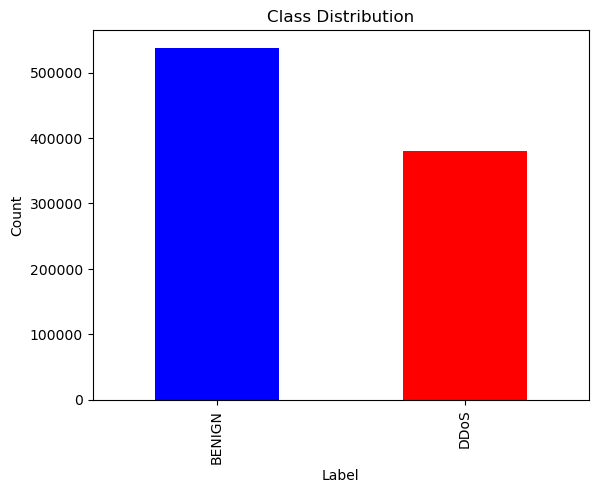

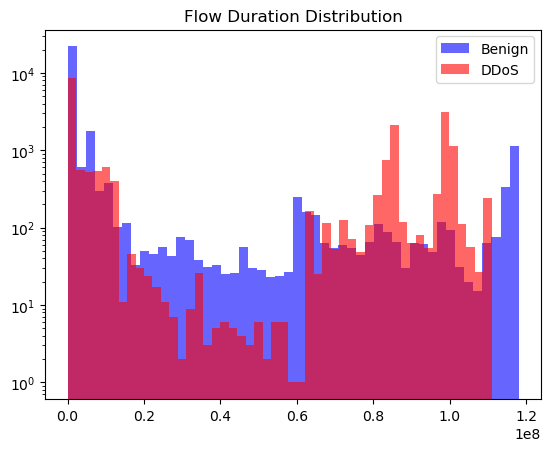

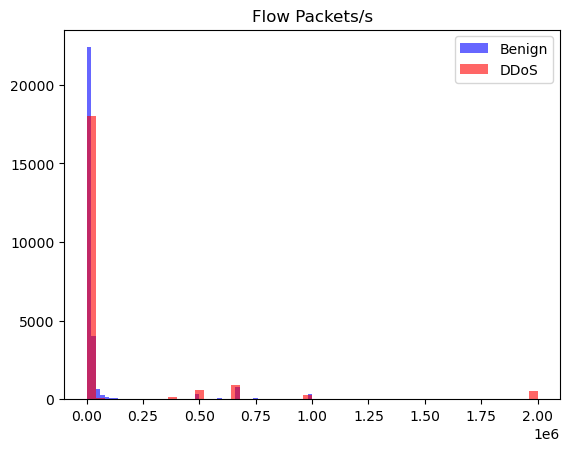

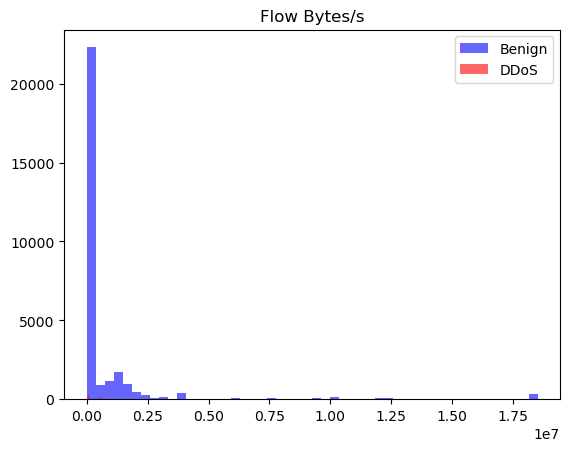

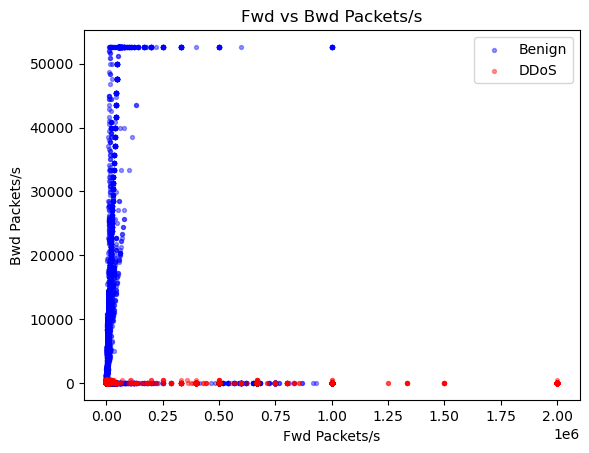

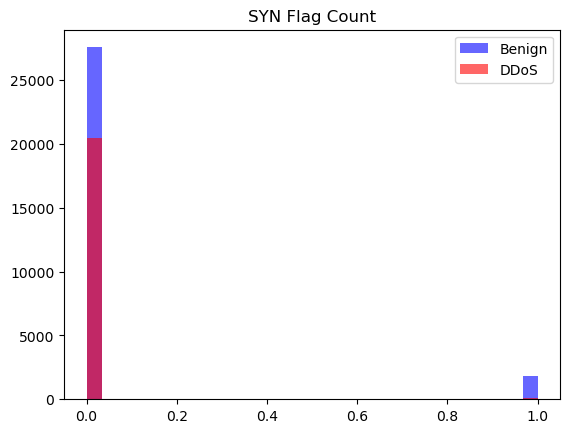

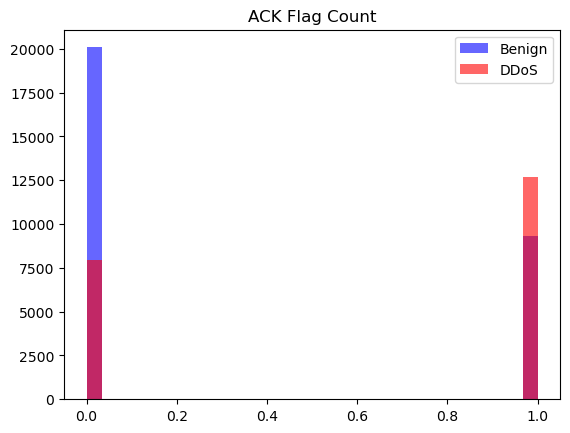

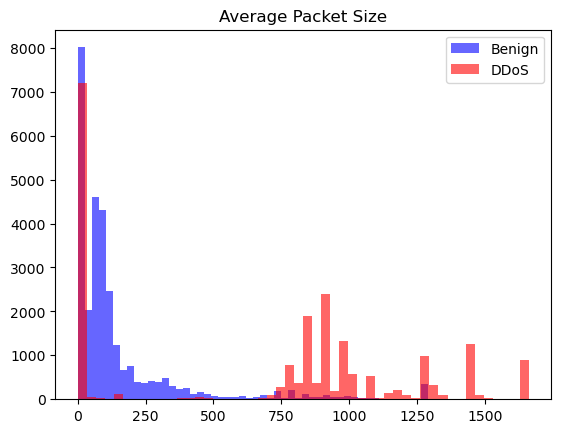

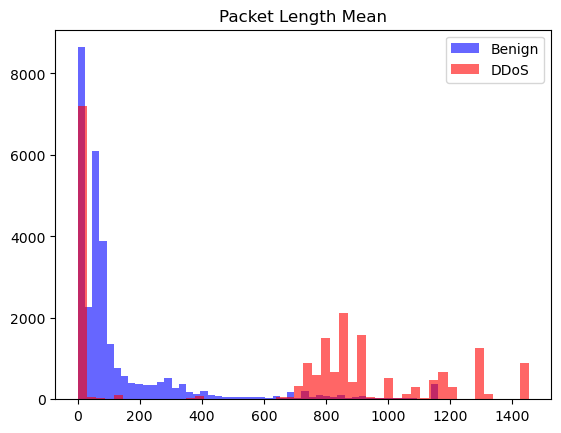

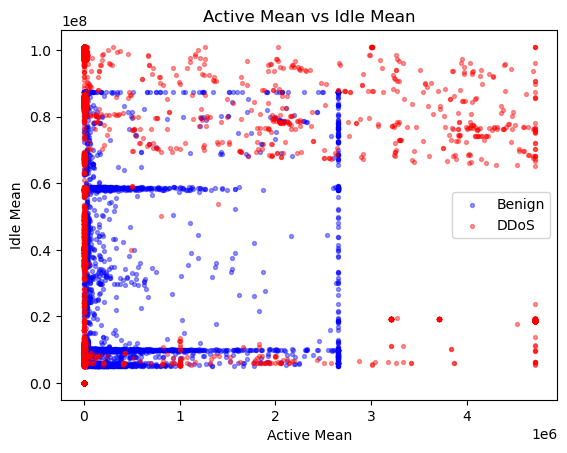

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ===============================
# 1. LOAD & PREPROCESS
# ===============================
df = pd.read_csv("file_updated.csv")
df.columns = df.columns.str.strip()
df["Label_bin"] = (df["Label"].str.upper() == "DDOS").astype(int)

# Sample cho nhẹ
df_plot = df.sample(50000, random_state=42)

# ===============================
# 2. CLEAN DATA FOR VISUALIZATION
# ===============================
def clean_df_for_plot(df_sub, cols):
    df_c = df_sub[cols].replace([np.inf, -np.inf], np.nan)
    df_c = df_c.dropna()
    for c in cols:
        df_c = df_c[df_c[c] >= 0]
        upper = df_c[c].quantile(0.99)
        df_c[c] = df_c[c].clip(upper=upper)
    return df_c

# ===============================
# 1. CLASS DISTRIBUTION
# ===============================
plt.figure()
df["Label"].value_counts().plot(
    kind="bar", color=["blue", "red"]
)
plt.title("Class Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

# ===============================
# 2. FLOW DURATION
# ===============================
plt.figure()
plt.hist(
    clean_df_for_plot(df_plot[df_plot.Label_bin==0], ["Flow Duration"])["Flow Duration"],
    bins=50, alpha=0.6, label="Benign", color="blue"
)
plt.hist(
    clean_df_for_plot(df_plot[df_plot.Label_bin==1], ["Flow Duration"])["Flow Duration"],
    bins=50, alpha=0.6, label="DDoS", color="red"
)
plt.yscale("log")
plt.title("Flow Duration Distribution")
plt.legend()
plt.show()

# ===============================
# 3. FLOW PACKETS/S
# ===============================
plt.figure()
plt.hist(
    clean_df_for_plot(df_plot[df_plot.Label_bin==0], ["Flow Packets/s"])["Flow Packets/s"],
    bins=50, alpha=0.6, label="Benign", color="blue"
)
plt.hist(
    clean_df_for_plot(df_plot[df_plot.Label_bin==1], ["Flow Packets/s"])["Flow Packets/s"],
    bins=50, alpha=0.6, label="DDoS", color="red"
)
plt.title("Flow Packets/s")
plt.legend()
plt.show()

# ===============================
# 4. FLOW BYTES/S
# ===============================
plt.figure()
plt.hist(
    clean_df_for_plot(df_plot[df_plot.Label_bin==0], ["Flow Bytes/s"])["Flow Bytes/s"],
    bins=50, alpha=0.6, label="Benign", color="blue"
)
plt.hist(
    clean_df_for_plot(df_plot[df_plot.Label_bin==1], ["Flow Bytes/s"])["Flow Bytes/s"],
    bins=50, alpha=0.6, label="DDoS", color="red"
)
plt.title("Flow Bytes/s")
plt.legend()
plt.show()

# ===============================
# 5. FWD vs BWD PACKETS/S
# ===============================
plt.figure()

benign = clean_df_for_plot(
    df_plot[df_plot.Label_bin==0],
    ["Fwd Packets/s", "Bwd Packets/s"]
)
ddos = clean_df_for_plot(
    df_plot[df_plot.Label_bin==1],
    ["Fwd Packets/s", "Bwd Packets/s"]
)

plt.scatter(
    benign["Fwd Packets/s"], benign["Bwd Packets/s"],
    s=8, alpha=0.4, label="Benign", color="blue"
)
plt.scatter(
    ddos["Fwd Packets/s"], ddos["Bwd Packets/s"],
    s=8, alpha=0.4, label="DDoS", color="red"
)

plt.xlabel("Fwd Packets/s")
plt.ylabel("Bwd Packets/s")
plt.title("Fwd vs Bwd Packets/s")
plt.legend()
plt.show()

# ===============================
# 6. SYN FLAG COUNT
# ===============================
plt.figure()
plt.hist(df_plot[df_plot.Label_bin==0]["SYN Flag Count"],
         bins=30, alpha=0.6, label="Benign", color="blue")
plt.hist(df_plot[df_plot.Label_bin==1]["SYN Flag Count"],
         bins=30, alpha=0.6, label="DDoS", color="red")
plt.title("SYN Flag Count")
plt.legend()
plt.show()

# ===============================
# 7. ACK FLAG COUNT
# ===============================
plt.figure()
plt.hist(df_plot[df_plot.Label_bin==0]["ACK Flag Count"],
         bins=30, alpha=0.6, label="Benign", color="blue")
plt.hist(df_plot[df_plot.Label_bin==1]["ACK Flag Count"],
         bins=30, alpha=0.6, label="DDoS", color="red")
plt.title("ACK Flag Count")
plt.legend()
plt.show()

# ===============================
# 8. AVERAGE PACKET SIZE
# ===============================
plt.figure()
plt.hist(
    clean_df_for_plot(df_plot[df_plot.Label_bin==0], ["Average Packet Size"])["Average Packet Size"],
    bins=50, alpha=0.6, label="Benign", color="blue"
)
plt.hist(
    clean_df_for_plot(df_plot[df_plot.Label_bin==1], ["Average Packet Size"])["Average Packet Size"],
    bins=50, alpha=0.6, label="DDoS", color="red"
)
plt.title("Average Packet Size")
plt.legend()
plt.show()

# ===============================
# 9. PACKET LENGTH MEAN
# ===============================
plt.figure()
plt.hist(
    clean_df_for_plot(df_plot[df_plot.Label_bin==0], ["Packet Length Mean"])["Packet Length Mean"],
    bins=50, alpha=0.6, label="Benign", color="blue"
)
plt.hist(
    clean_df_for_plot(df_plot[df_plot.Label_bin==1], ["Packet Length Mean"])["Packet Length Mean"],
    bins=50, alpha=0.6, label="DDoS", color="red"
)
plt.title("Packet Length Mean")
plt.legend()
plt.show()

# ===============================
# 10. ACTIVE vs IDLE MEAN
# ===============================
plt.figure()

benign = clean_df_for_plot(
    df_plot[df_plot.Label_bin==0],
    ["Active Mean", "Idle Mean"]
)
ddos = clean_df_for_plot(
    df_plot[df_plot.Label_bin==1],
    ["Active Mean", "Idle Mean"]
)

plt.scatter(
    benign["Active Mean"], benign["Idle Mean"],
    s=8, alpha=0.4, label="Benign", color="blue"
)
plt.scatter(
    ddos["Active Mean"], ddos["Idle Mean"],
    s=8, alpha=0.4, label="DDoS", color="red"
)

plt.xlabel("Active Mean")
plt.ylabel("Idle Mean")
plt.title("Active Mean vs Idle Mean")
plt.legend()
plt.show()


In [47]:
# Danh sách cột nhiễu / không cần thiết
cols_to_drop = [
    'Destination Port', 'Fwd Header Length.1', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 
    'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate', 
    'Init_Win_bytes_forward', 'Init_Win_bytes_backward', 'act_data_pkt_fwd', 'min_seg_size_forward', 
    'CWE Flag Count', 'ECE Flag Count'
]

# Drop các cột này khỏi DataFrame
df = df.drop(columns=cols_to_drop)
df = df.dropna()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 917436 entries, 0 to 918447
Data columns (total 65 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Flow Duration                917436 non-null  int64  
 1   Total Fwd Packets            917436 non-null  int64  
 2   Total Backward Packets       917436 non-null  int64  
 3   Total Length of Fwd Packets  917436 non-null  int64  
 4   Total Length of Bwd Packets  917436 non-null  int64  
 5   Fwd Packet Length Max        917436 non-null  int64  
 6   Fwd Packet Length Min        917436 non-null  int64  
 7   Fwd Packet Length Mean       917436 non-null  float64
 8   Fwd Packet Length Std        917436 non-null  float64
 9   Bwd Packet Length Max        917436 non-null  int64  
 10  Bwd Packet Length Min        917436 non-null  int64  
 11  Bwd Packet Length Mean       917436 non-null  float64
 12  Bwd Packet Length Std        917436 non-null  float64
 13  Flow

In [48]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# Danh sách cột numeric cần xử lý
numeric_cols = [
    'Flow Bytes/s', 'Flow Packets/s',
    'Flow Duration',
    'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
    'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min',
    'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min',
    'Total Fwd Packets', 'Total Backward Packets',
    'Total Length of Fwd Packets', 'Total Length of Bwd Packets',
    'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std',
    'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std',
    'Fwd Packets/s', 'Bwd Packets/s',
    'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance',
    'Average Packet Size', 'Avg Fwd Segment Size', 'Avg Bwd Segment Size',
    'Active Mean', 'Active Std', 'Active Max', 'Active Min', 'Idle Mean', 'Idle Std', 'Idle Max', 'Idle Min'
]

# 1. Thay inf bằng median
for col in numeric_cols:
    if col in df.columns:
        median_val = df.loc[df[col] != np.inf, col].median()
        df[col] = df[col].replace(np.inf, median_val)

# 2. Thay giá trị âm bằng 0
for col in numeric_cols:
    if col in df.columns:
        df[col] = df[col].apply(lambda x: 0 if x < 0 else x)

# 3. Capping outliers quá cao (percentile 99%)
for col in numeric_cols:
    if col in df.columns:
        upper = df[col].quantile(0.99)
        df[col] = np.where(df[col] > upper, upper, df[col])

# 4. Scaling chuẩn hóa dữ liệu
scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

print("✅ Numeric columns processed and scaled successfully.")

✅ Numeric columns processed and scaled successfully.


In [49]:
#in ra đầy đủ và lưu vào .csv để dễ đọc 
df.describe().to_csv('data_description.csv')

In [50]:
df.columns

Index(['Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
       'Total Length of Fwd Packets', 'Total Length of Bwd Packets',
       'Fwd Packet Length Max', 'Fwd Packet Length Min',
       'Fwd Packet Length Mean', 'Fwd Packet Length Std',
       'Bwd Packet Length Max', 'Bwd Packet Length Min',
       'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s',
       'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max',
       'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std',
       'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean',
       'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags',
       'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Min Packet Length', 'Max Packet Length', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       'SYN Flag Count', 'RST Flag Count', 'PS

In [51]:
import numpy as np

# Check for infinite values
inf_mask = np.isinf(df.select_dtypes(include=[np.number]))
inf_columns = inf_mask.any()
print("Columns with inf values:\n", inf_columns[inf_columns].index.tolist())
df_clean = df.replace([np.inf, -np.inf], np.nan).dropna()

Columns with inf values:
 []


In [52]:
print("Remaining inf:", np.isinf(df_clean.select_dtypes(include=[np.number])).any().any())
print("Remaining NaN:", df_clean.isna().any().any())

Remaining inf: False
Remaining NaN: False


In [53]:
X = df_clean.drop('Label', axis=1)
y = df_clean['Label']

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

In [55]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

              precision    recall  f1-score   support

      BENIGN  0.9976743 0.9892968 0.9934679    107538
        DDoS  0.9850234 0.9967347 0.9908444     75950

    accuracy                      0.9923755    183488
   macro avg  0.9913488 0.9930158 0.9921562    183488
weighted avg  0.9924378 0.9923755 0.9923820    183488

Confusion Matrix:
 [[106387   1151]
 [   248  75702]]


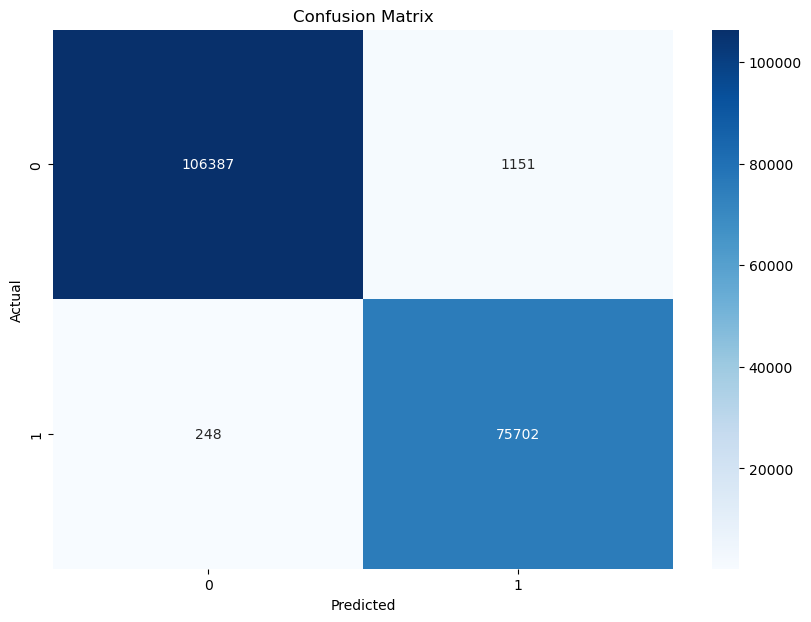

Accuracy: 0.9923755231949773


In [56]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred, digits=7))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
#Vẽ biểu đồ ma trận nhầm lẫn
import matplotlib.pyplot as plt
import seaborn as sns
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()
print("Accuracy:",accuracy_score(y_test, y_pred, normalize=True))

In [62]:
import joblib
joblib.dump(model, 'ddos_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(df_clean.columns, 'feature_columns.pkl')

['feature_columns.pkl']

In [ ]:
import pandas as pd
import numpy as np
import joblib
from sklearn.metrics import accuracy_score, f1_score, classification_report
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
# Load model, scaler, train_columns
model = joblib.load("ddos_model.pkl")
scaler = joblib.load("scaler.pkl")
train_columns = joblib.load("feature_columns.pkl")
feature_columns = train_columns[:-1]  # exclude 'Label'

# 1. Load data
data = pd.read_csv("file_updated.csv")
data.columns = data.columns.str.strip()
data = data.replace([np.inf, -np.inf], np.nan).dropna()
#Loại bỏ các features không cần thiết giống như trong quá trình huấn luyện
cols_to_drop = [
    'Destination Port', 'Fwd Header Length.1', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 
    'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate', 
    'Init_Win_bytes_forward', 'Init_Win_bytes_backward', 'act_data_pkt_fwd', 'min_seg_size_forward', 
    'CWE Flag Count', 'ECE Flag Count'
]
data = data.drop(columns=cols_to_drop)
data = data.dropna()
# 2. Scale data
X = data[feature_columns]
y_true = data['Label']
X_scaled = scaler.transform(X)
# 3. không cần chunk
# 4. Predict
y_pred = model.predict(X_scaled)
y_true_all = y_true
# 5. Evaluate
print(classification_report(y_true_all, y_pred, digits=7))
print("Confusion Matrix:\n", confusion_matrix(y_true_all, y_pred))
#Vẽ biểu đồ ma trận nhầm lẫn
import matplotlib.pyplot as plt
import seaborn as sns
cm = confusion_matrix(y_true_all, y_pred)
plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()
print("Accuracy:",accuracy_score(y_true_all, y_pred, normalize=True))


ValueError: The feature names should match those that were passed during fit.
Feature names seen at fit time, yet now missing:
- Bwd Header Length


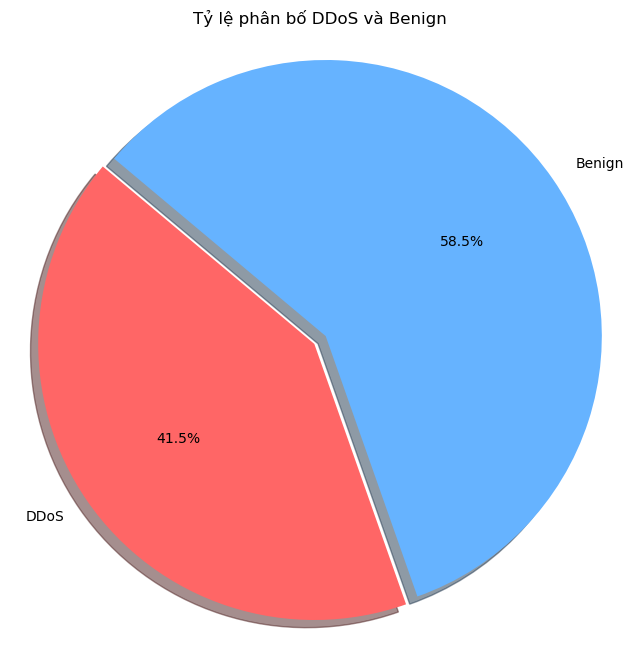

In [81]:
import matplotlib.pyplot as plt

# Dữ liệu
labels = ['DDoS', 'Benign']
sizes = [41.5, 58.5]
colors = ['#ff6666', '#66b3ff']  # Màu đỏ cho DDoS, xanh cho Benign
explode = (0.05, 0)  # Tách nhẹ phần DDoS ra để nổi bật

# Tạo biểu đồ
plt.figure(figsize=(8, 8))
plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
        shadow=True, startangle=140)

plt.title('Tỷ lệ phân bố DDoS và Benign')
plt.axis('equal')  # Đảm bảo biểu đồ vẽ thành hình tròn

# Hiển thị biểu đồ
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

# ================================
# 1. Load dữ liệu
# ================================
df = pd.read_csv('file_updated.csv')
df.columns = df.columns.str.strip()

# ================================
# 2. Feature list
# ================================
feature_cols = [
    'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
    'Total Length of Fwd Packets', 'Total Length of Bwd Packets',
    'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std',
    'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std',
    'Flow Bytes/s', 'Flow Packets/s', 'Fwd Packets/s', 'Bwd Packets/s',
    'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
    'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min',
    'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min',
    'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count',
    'Active Mean', 'Active Std', 'Active Max', 'Active Min',
    'Idle Mean', 'Idle Std', 'Idle Max', 'Idle Min',
    'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance',
    'Average Packet Size', 'Avg Fwd Segment Size', 'Avg Bwd Segment Size',
    'Fwd Header Length', 'Bwd Header Length',
    'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags',
    'Down/Up Ratio', 'Subflow Fwd Packets', 'Subflow Fwd Bytes',
    'Subflow Bwd Packets', 'Subflow Bwd Bytes'
]

# Chỉ giữ các cột có trong dataset
feature_cols = [col for col in feature_cols if col in df.columns]
X = df[feature_cols].copy()
y = (df['Label'].astype(str).str.upper() == 'DDOS').astype(int)  # BENIGN=0, DDoS=1

# ================================
# 3. Chuẩn hóa dữ liệu numeric
# ================================
upper_bounds = {}   # percentile 99% cho deploy
medians = {}        # median để xử lý inf/NaN

for col in feature_cols:
    # 1. Convert numeric
    X[col] = pd.to_numeric(X[col], errors='coerce')

    # 2. Thay NaN hoặc inf bằng median
    med = X[col].median()
    X[col] = X[col].replace([np.inf, -np.inf], med)
    X[col] = X[col].fillna(med)
    medians[col] = med

    # 3. Thay giá trị âm bằng 0
    X[col] = X[col].apply(lambda x: 0 if x < 0 else x)

    # 4. Capping percentile 99%
    upper = X[col].quantile(0.99)
    X[col] = np.where(X[col] > upper, upper, X[col])
    upper_bounds[col] = upper

# ================================
# 4. Scaling
# ================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ================================
# 5. Train/test split
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# ================================
# 6. Train Random Forest
# ================================
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

# ================================
# 7. Đánh giá
# ================================
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, digits=7))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

plt.figure(figsize=(10,7))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# ================================
# 8. Lưu model & metadata
# ================================
joblib.dump(rf_model, 'rf_ddos_model.pkl')
joblib.dump(scaler, 'rf_scaler.pkl')
joblib.dump(feature_cols, 'rf_feature_columns.pkl')
joblib.dump(medians, 'rf_feature_medians.pkl')
joblib.dump(upper_bounds, 'rf_feature_upper_bounds.pkl')

## Merged

              precision    recall  f1-score   support

      BENIGN  0.9977393 0.9889540 0.9933272    107550
        DDoS  0.9845888 0.9968348 0.9906740     76140

    accuracy                      0.9922206    183690
   macro avg  0.9911641 0.9928944 0.9920006    183690
weighted avg  0.9922884 0.9922206 0.9922274    183690

Confusion Matrix:
 [[106362   1188]
 [   241  75899]]
Accuracy: 0.9922205890358756


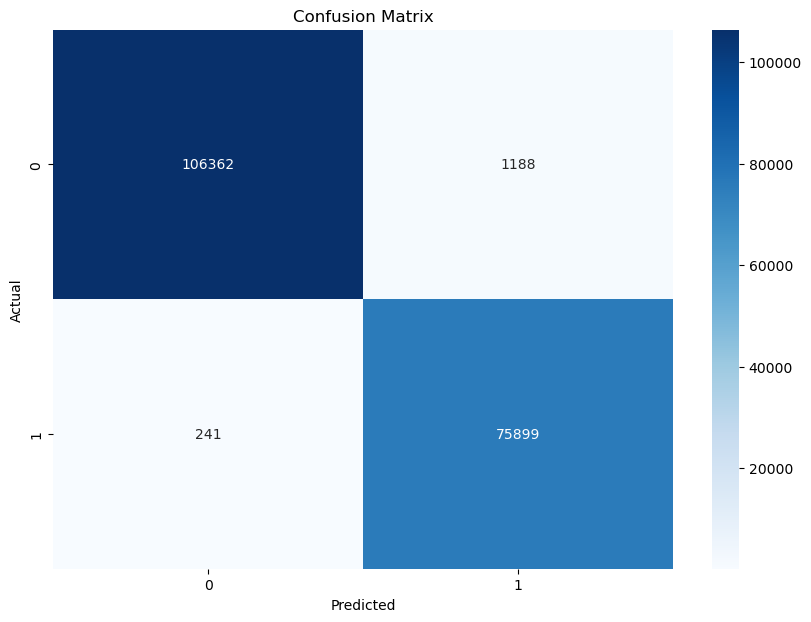

['rf_feature_upper_bounds.pkl']

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.model_selection import learning_curve
import seaborn as sns

df = pd.read_csv('file_updated.csv')
df.columns = df.columns.str.strip()

# Feature quan trọng đã chọn (loại bỏ các cột nhiễu)
feature_cols = [
    'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
    'Total Length of Fwd Packets', 'Total Length of Bwd Packets',
    'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std',
    'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std',
    'Flow Bytes/s', 'Flow Packets/s', 'Fwd Packets/s', 'Bwd Packets/s',
    'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
    'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min',
    'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min',
    'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count',
    'Active Mean', 'Active Std', 'Active Max', 'Active Min',
    'Idle Mean', 'Idle Std', 'Idle Max', 'Idle Min',
    'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance',
    'Average Packet Size', 'Avg Fwd Segment Size', 'Avg Bwd Segment Size',
    'Fwd Header Length', 'Bwd Header Length', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags',
    'Down/Up Ratio', 'Subflow Fwd Packets', 'Subflow Fwd Bytes',
    'Subflow Bwd Packets', 'Subflow Bwd Bytes'
]

feature_cols = [col for col in feature_cols if col in df.columns]

X = df[feature_cols].copy()

y = (df['Label'].astype(str).str.upper() == 'DDOS').astype(int)
# BENIGN -> 0 | DDoS -> 1

upper_bounds = {}
medians = {}

for col in feature_cols:
    med = X.loc[X[col] != np.inf, col].median()
    medians[col] = med
    X[col] = X[col].replace(np.inf, med)

    X[col] = X[col].apply(lambda x: 0 if x < 0 else x)

    upper = X[col].quantile(0.99)
    upper_bounds[col] = upper
    X[col] = np.where(X[col] > upper, upper, X[col])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

y_prob = rf_model.predict_proba(X_test)[:, 1]

print(
    classification_report(
        y_test,
        y_pred,
        target_names=['BENIGN', 'DDoS'],
        digits=7
    )
)

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

joblib.dump(rf_model, 'rf_ddos_model.pkl')
joblib.dump(scaler, 'rf_scaler.pkl')
joblib.dump(feature_cols, 'rf_feature_columns.pkl')
joblib.dump(medians, 'rf_feature_medians.pkl')
joblib.dump(upper_bounds, 'rf_feature_upper_bounds.pkl')

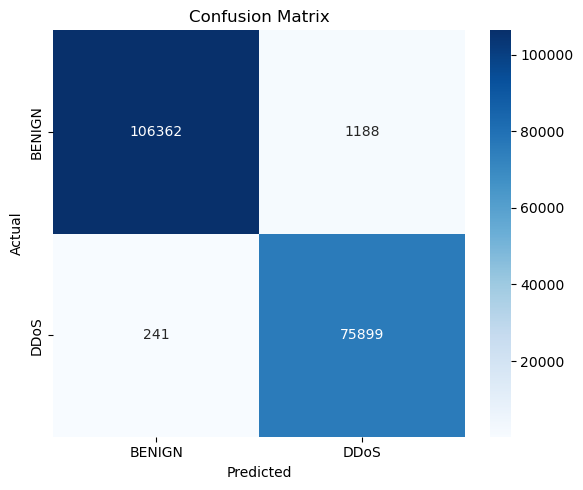

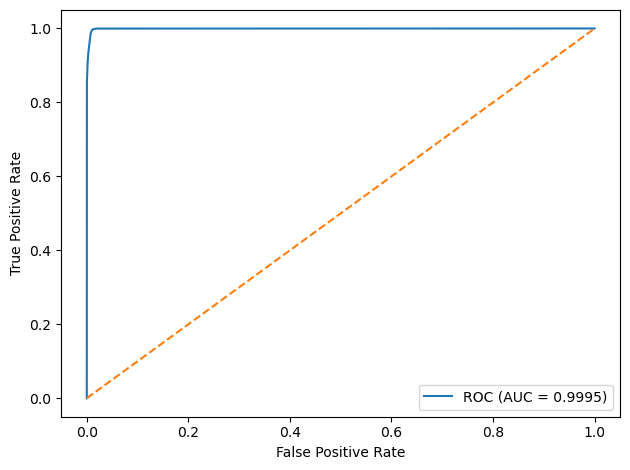

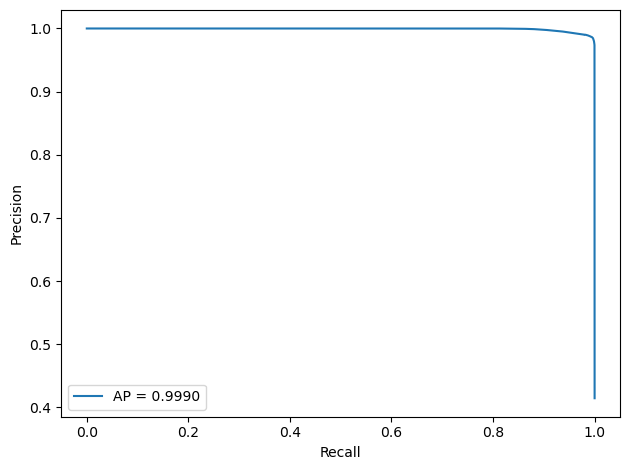

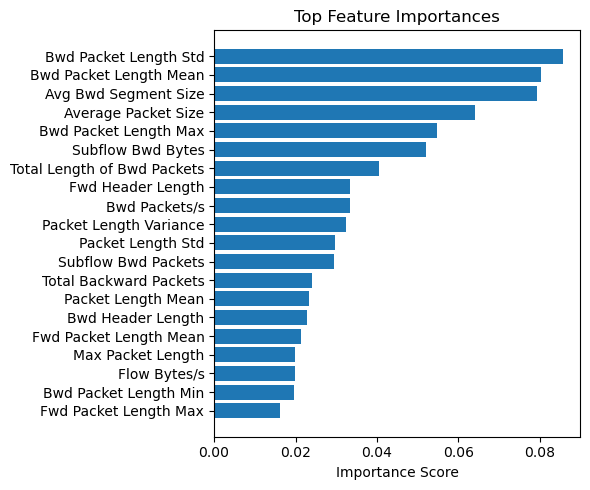

In [ ]:
# ---- Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["BENIGN", "DDoS"],
            yticklabels=["BENIGN", "DDoS"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_prob, pos_label=1)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

precision, recall, _ = precision_recall_curve(
    y_test, y_prob, pos_label=1
)
ap = average_precision_score(
    y_test, y_prob, pos_label=1
)

plt.figure()
plt.plot(recall, precision, label=f"AP = {ap:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.tight_layout()
plt.show()

importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

top_k = 20
plt.figure(figsize=(6, 5))
plt.barh(
    range(top_k),
    importances[indices][:top_k][::-1]
)
plt.yticks(
    range(top_k),
    [feature_cols[i] for i in indices[:top_k]][::-1]
)
plt.xlabel("Importance Score")
plt.title("Top Feature Importances")
plt.tight_layout()
plt.show()

Số features đã train trong model: 64
Classification Report:
              precision    recall  f1-score   support

      BENIGN  0.9981234 0.9900902 0.9940906    537749
        DDoS  0.9861594 0.9973706 0.9917333    380699

    accuracy                      0.9931079    918448
   macro avg  0.9921414 0.9937304 0.9929120    918448
weighted avg  0.9931643 0.9931079 0.9931135    918448

Confusion Matrix:
 [[532420   5329]
 [  1001 379698]]
Accuracy: 0.9931079386094803


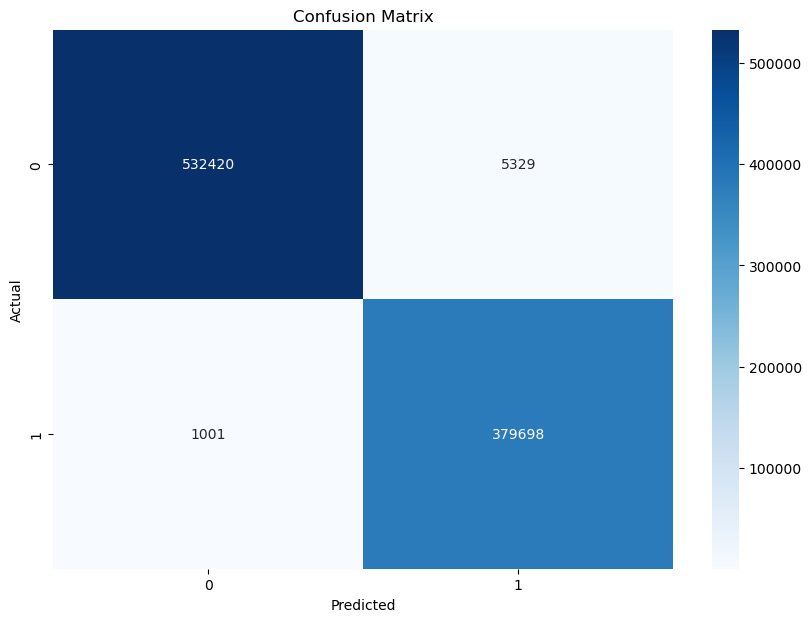

In [ ]:
import pandas as pd
import numpy as np
import joblib
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

def test_rf_model(csv_file):

    model = joblib.load('rf_ddos_model.pkl')
    scaler = joblib.load('rf_scaler.pkl')
    feature_columns = joblib.load('rf_feature_columns.pkl')
    medians = joblib.load('rf_feature_medians.pkl')
    upper_bounds = joblib.load('rf_feature_upper_bounds.pkl')

    print(f"Số features đã train trong model: {len(feature_columns)}")

    pd.DataFrame(feature_columns, columns=['Feature']).to_csv('rf_model_features.csv', index=False)

    data = pd.read_csv(csv_file)
    data.columns = data.columns.str.strip() 

    X = pd.DataFrame()
    for col in feature_columns:
        if col in data.columns:
            X[col] = data[col]
        else:
            X[col] = 0 
    
    X = X[feature_columns]
    
    for col in feature_columns:
        X[col] = X[col].replace([np.inf, -np.inf], medians[col])
        X[col] = X[col].clip(lower=0, upper=upper_bounds[col])
    
    X_scaled = scaler.transform(X)

    if 'Label' in data.columns:
        y_true = (data['Label'].astype(str).str.upper() == 'DDOS').astype(int)

    else:
        raise ValueError("File test không có cột 'Label'")
    
    y_pred = model.predict(X_scaled)
    
    print("Classification Report:")
    print(classification_report(y_true, y_pred, target_names=['BENIGN', 'DDoS'],digits=7))
    
    cm = confusion_matrix(y_true, y_pred)
    print("Confusion Matrix:\n", cm)
    print("Accuracy:", accuracy_score(y_true, y_pred))

    plt.figure(figsize=(10,7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()
    
    return y_pred, y_true

y_pred, y_true = test_rf_model("file_updated.csv")


Classification Report:
              precision    recall  f1-score   support

      BENIGN  0.9930632 0.9645113 0.9785790    537749
        DDoS  0.9518275 0.9904833 0.9707708    380699

    accuracy                      0.9752768    918448
   macro avg  0.9724454 0.9774973 0.9746749    918448
weighted avg  0.9759709 0.9752768 0.9753425    918448

Confusion Matrix:
 [[518665  19084]
 [  3623 377076]]
Accuracy: 0.9752767712488895


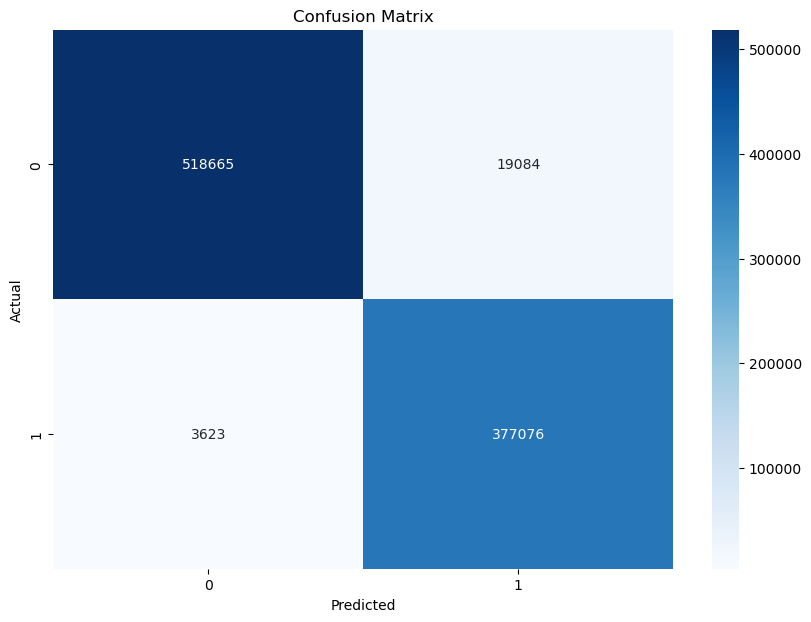

In [ ]:
import pandas as pd
import numpy as np
import joblib
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

def test_rf_model(csv_file):

    model = joblib.load('logistic_ddos_model.pkl')
    scaler = joblib.load('logistic_scaler.pkl')
    feature_columns = joblib.load('logistic_feature_columns.pkl')
    medians = joblib.load('logistic_feature_medians.pkl')
    upper_bounds = joblib.load('logistic_feature_upper_bounds.pkl')
    

    data = pd.read_csv(csv_file)
    data.columns = data.columns.str.strip()  
    
    X = pd.DataFrame()
    for col in feature_columns:
        if col in data.columns:
            X[col] = data[col]
        else:
            X[col] = 0  
    
    X = X[feature_columns]
    
    for col in feature_columns:
        X[col] = X[col].replace([np.inf, -np.inf], medians[col])

        X[col] = X[col].fillna(medians[col])

        X[col] = X[col].clip(lower=0, upper=upper_bounds[col])

    
    X_scaled = scaler.transform(X)
    
    if 'Label' in data.columns:
        y_true = (data['Label'].astype(str).str.upper() == 'DDOS').astype(int)

    else:
        raise ValueError("File test không có cột 'Label'")
    
    y_pred = model.predict(X_scaled)
    
    print("Classification Report:")
    print(classification_report(y_true, y_pred, target_names=['BENIGN', 'DDoS'],digits=7))
    
    cm = confusion_matrix(y_true, y_pred)
    print("Confusion Matrix:\n", cm)
    print("Accuracy:", accuracy_score(y_true, y_pred))
    
    plt.figure(figsize=(10,7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()
    
    return y_pred, y_true

y_pred, y_true = test_rf_model("file_updated.csv")


In [ ]:
import pandas as pd
import numpy as np
import joblib

def predict_rf_model(csv_file, output_file="predicted.csv"):
    model = joblib.load('rf_ddos_model.pkl')
    scaler = joblib.load('rf_scaler.pkl')
    feature_columns = joblib.load('rf_feature_columns.pkl')
    medians = joblib.load('rf_feature_medians.pkl')
    upper_bounds = joblib.load('rf_feature_upper_bounds.pkl')
    
    data = pd.read_csv(csv_file)
    data.columns = data.columns.str.strip()
    
    X = pd.DataFrame()
    for col in feature_columns:
        if col in data.columns:
            X[col] = data[col]
        else:
            X[col] = 0  
    
    X = X[feature_columns]
    
    for col in feature_columns:
        X[col] = X[col].replace([np.inf, -np.inf], medians[col])
        X[col] = X[col].fillna(medians[col])
        X[col] = X[col].clip(lower=0, upper=upper_bounds[col])
    
    X_scaled = scaler.transform(X)
    
    y_pred = model.predict(X_scaled)
    
    result = data.copy()
    result['Predicted_Label'] = y_pred
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_scaled)
        for i, class_label in enumerate(model.classes_):
            result[f'Prob_{class_label}'] = y_proba[:, i]
    result.to_csv(output_file, index=False)
    
    print(f"Dự đoán xong, lưu kết quả vào '{output_file}'")
    return y_pred

y_pred = predict_rf_model("live_flowl_last_2.csv", output_file="predicted_results.csv")
import numpy as np
label_mapping = {0: 'BENIGN', 1: 'DDoS'}
predicted_labels = [label_mapping[label] for label in y_pred]
for i in range(0, len(predicted_labels), 10):
    print(predicted_labels[i:i+10])

Dự đoán xong, lưu kết quả vào 'predicted_results.csv'
['DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS']
['DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS']
['DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS']
['DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS']
['DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS']
['DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS']
['DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS']
['DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS']
['DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS']
['DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS']
['DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS']
['DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS'

## Logistic 

/media/haduckien/E/Tool/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


              precision    recall  f1-score   support

      BENIGN   0.993370  0.964063  0.978497    107550
        DDoS   0.951269  0.990911  0.970686     76140

    accuracy                       0.975192    183690
   macro avg   0.972320  0.977487  0.974591    183690
weighted avg   0.975919  0.975192  0.975259    183690



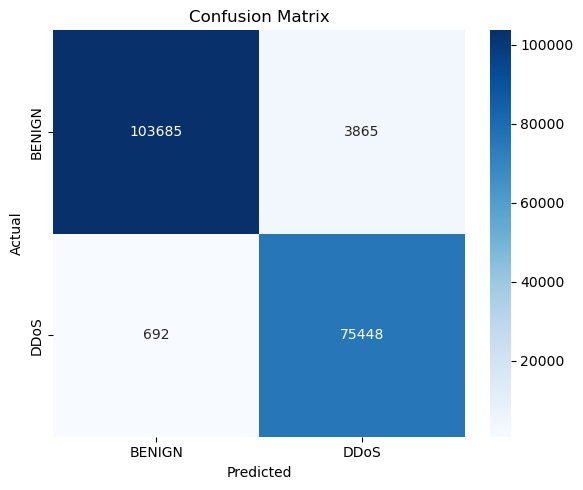

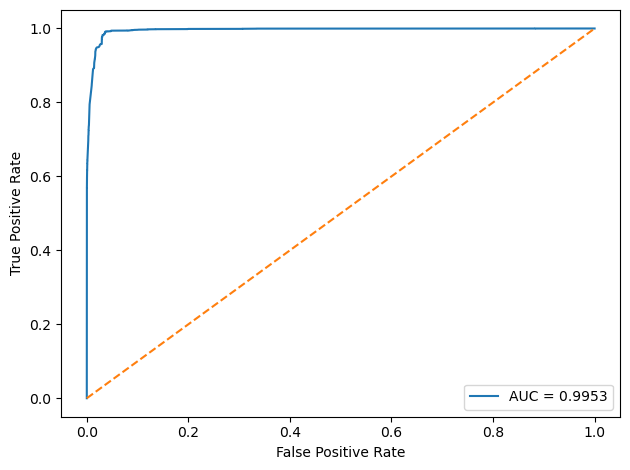

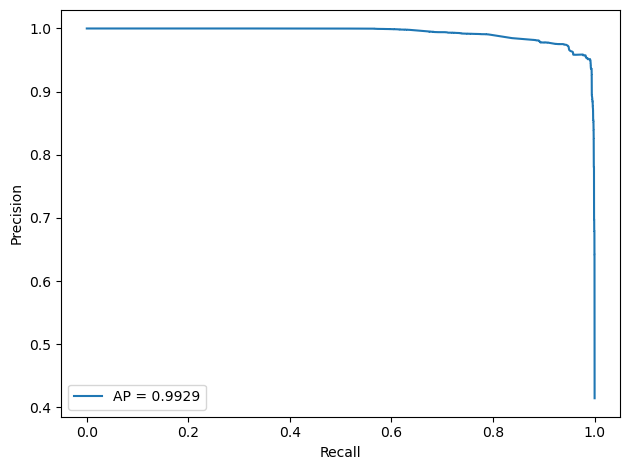

['logistic_feature_upper_bounds.pkl']

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)

df = pd.read_csv("file_updated.csv")
df.columns = df.columns.str.strip()

feature_cols = [
    'Flow Duration','Total Fwd Packets','Total Backward Packets',
    'Total Length of Fwd Packets','Total Length of Bwd Packets',
    'Fwd Packet Length Max','Fwd Packet Length Min',
    'Fwd Packet Length Mean','Fwd Packet Length Std',
    'Bwd Packet Length Max','Bwd Packet Length Min',
    'Bwd Packet Length Mean','Bwd Packet Length Std',
    'Flow Bytes/s','Flow Packets/s',
    'Fwd Packets/s','Bwd Packets/s',
    'Flow IAT Mean','Flow IAT Std','Flow IAT Max','Flow IAT Min',
    'Fwd IAT Total','Fwd IAT Mean','Fwd IAT Std',
    'Fwd IAT Max','Fwd IAT Min',
    'Bwd IAT Total','Bwd IAT Mean','Bwd IAT Std',
    'Bwd IAT Max','Bwd IAT Min',
    'FIN Flag Count','SYN Flag Count','RST Flag Count',
    'PSH Flag Count','ACK Flag Count','URG Flag Count',
    'Active Mean','Active Std','Active Max','Active Min',
    'Idle Mean','Idle Std','Idle Max','Idle Min',
    'Min Packet Length','Max Packet Length',
    'Packet Length Mean','Packet Length Std','Packet Length Variance',
    'Average Packet Size','Avg Fwd Segment Size','Avg Bwd Segment Size',
    'Fwd Header Length','Bwd Header Length',
    'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags',
    'Down/Up Ratio', 'Subflow Fwd Packets', 'Subflow Fwd Bytes',
    'Subflow Bwd Packets', 'Subflow Bwd Bytes'
]

feature_cols = [c for c in feature_cols if c in df.columns]
X = df[feature_cols].copy()

y = (df["Label"].astype(str).str.upper() == "DDOS").astype(int)

medians = {}
upper_bounds = {}

for col in feature_cols:
    med = X[col].replace([np.inf, -np.inf], np.nan).median()
    medians[col] = med

    X[col] = X[col].replace([np.inf, -np.inf], np.nan)
    X[col] = X[col].fillna(med)

    X[col] = X[col].clip(lower=0)

    upper = X[col].quantile(0.99)
    upper_bounds[col] = upper
    X[col] = np.where(X[col] > upper, upper, X[col])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

log_model = LogisticRegression(
    max_iter=1000,
    solver="lbfgs",
    n_jobs=-1
)
log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)
y_prob = log_model.predict_proba(X_test)[:, 1]

print(classification_report(
    y_test, y_pred,
    target_names=["BENIGN", "DDoS"],
    digits=6
))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=["BENIGN","DDoS"],
            yticklabels=["BENIGN","DDoS"],
            cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1],[0,1],"--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

precision, recall, _ = precision_recall_curve(y_test, y_prob)
ap = average_precision_score(y_test, y_prob)

plt.figure()
plt.plot(recall, precision, label=f"AP = {ap:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.tight_layout()
plt.show()

joblib.dump(log_model, "logistic_ddos_model.pkl")
joblib.dump(scaler, "logistic_scaler.pkl")
joblib.dump(feature_cols, "logistic_feature_columns.pkl")
joblib.dump(medians, "logistic_feature_medians.pkl")
joblib.dump(upper_bounds, "logistic_feature_upper_bounds.pkl")

In [ ]:
import pandas as pd
import numpy as np
import joblib

def predict_rf_model(csv_file, output_file="predicted.csv"):
    # 1. Load model, scaler, feature, median & upper bounds
    model = joblib.load('logistic_ddos_model.pkl')
    scaler = joblib.load('logistic_scaler.pkl')
    feature_columns = joblib.load('logistic_feature_columns.pkl')
    medians = joblib.load('logistic_feature_medians.pkl')
    upper_bounds = joblib.load('logistic_feature_upper_bounds.pkl')
    
    data = pd.read_csv(csv_file)
    data.columns = data.columns.str.strip()
    
    X = pd.DataFrame()
    for col in feature_columns:
        if col in data.columns:
            X[col] = data[col]
        else:
            X[col] = 0 
    
    X = X[feature_columns]
    
    for col in feature_columns:
        X[col] = X[col].replace([np.inf, -np.inf], medians[col])
        X[col] = X[col].clip(lower=0, upper=upper_bounds[col])
    
    X_scaled = scaler.transform(X)
    
    y_pred = model.predict(X_scaled)
    
    result = data.copy()
    result['Predicted_Label'] = y_pred
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_scaled)
        for i, class_label in enumerate(model.classes_):
            result[f'Prob_{class_label}'] = y_proba[:, i]
    result.to_csv(output_file, index=False)
    
    print(f"Dự đoán xong, lưu kết quả vào '{output_file}'")
    return y_pred

y_pred = predict_rf_model("live_flowl_last_2.csv", output_file="predicted_logistic_results.csv")
label_mapping = {0: 'BENIGN', 1: 'DDoS'}
predicted_labels = [label_mapping[label] for label in y_pred]
for i in range(0, len(predicted_labels), 15):
    print(predicted_labels[i:i+15])

Dự đoán xong, lưu kết quả vào 'predicted_logistic_results.csv'
['DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS']
['DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS']
['DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS']
['DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS']
['DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS']
['DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS']
['DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS']
['DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', 'DDoS', '